# Unemployment Analysis in India

## Oasis Infobyte Data Science Internship — Task 2

### Objective

The objective of this project is to perform exploratory data analysis on unemployment data in India to identify regional and temporal trends and examine the impact of the COVID-19 period on unemployment rates.

### Tools and Technologies

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Dataset

The dataset used in this project contains information about unemployment rates, estimated employment, and labour participation rates across different regions of India from 2019 to 2020.

## 1. Import Libraries and Load Dataset

In [3]:
import os

# Show all files in the current Colab folder
os.listdir('/content')

['.config', 'Unemployment in India.csv', 'drive', 'sample_data']

In [4]:
df = pd.read_csv('/content/Unemployment in India.csv')

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 2. Dataset Overview

In [6]:
# Check the number of rows and columns
print("Number of rows and columns:", df.shape)

# Display the column names
print("\nColumn names:")
print(df.columns.tolist())

# Display information about the dataset
print("\nDataset Information:")
df.info()

Number of rows and columns: (768, 7)

Column names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory u

## 3. Data Cleaning and Preprocessing

In [7]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check the cleaned column names
print("Cleaned Column Names:")
print(df.columns.tolist())

# Check missing values in each column
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

Cleaned Column Names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

Missing Values in Each Column:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [8]:
# Remove rows where all values are missing
df = df.dropna(how='all')

# Convert the Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Check the dataset shape after removing empty rows
print("Dataset shape after cleaning:", df.shape)

# Check the data types
print("\nUpdated Data Types:")
print(df.dtypes)

# Check missing values again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Dataset shape after cleaning: (740, 7)

Updated Data Types:
Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

Missing Values After Cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


## 4. Exploratory Data Analysis

In [9]:
# Display descriptive statistics for numerical columns
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


### 4.1 Region-wise Average Unemployment Rate

In [10]:
# Calculate the average unemployment rate for each region
region_avg_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

# Display the average unemployment rate by region
print("Average Unemployment Rate by Region:")
print(region_avg_unemployment)

Average Unemployment Rate by Region:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


### 4.2 Top 10 Regions with Highest Average Unemployment

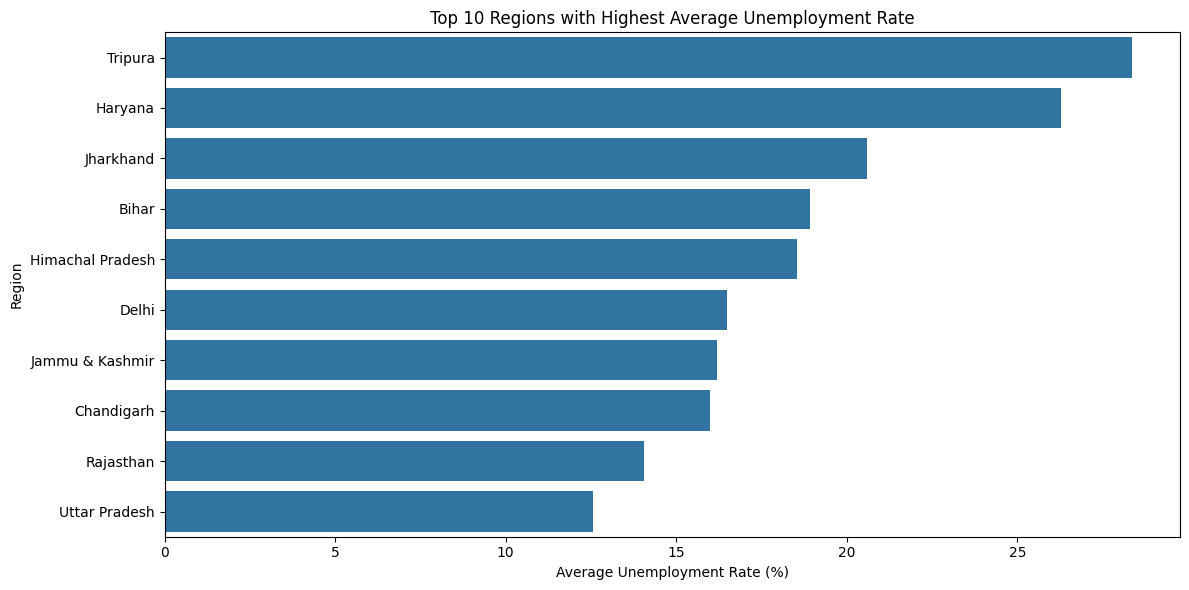

In [11]:
# Select the top 10 regions with the highest average unemployment rate
top_10_regions = region_avg_unemployment.head(10)

# Create the bar chart
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_10_regions.values,
    y=top_10_regions.index
)

plt.title('Top 10 Regions with Highest Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

### Observation

The bar chart shows that Tripura has the highest average unemployment rate among the regions in the dataset, followed by Haryana and Jharkhand. Meghalaya, Assam, and Odisha have comparatively lower average unemployment rates. The results indicate substantial differences in unemployment levels across different regions of India.

### 4.3 Month-wise Unemployment Trend

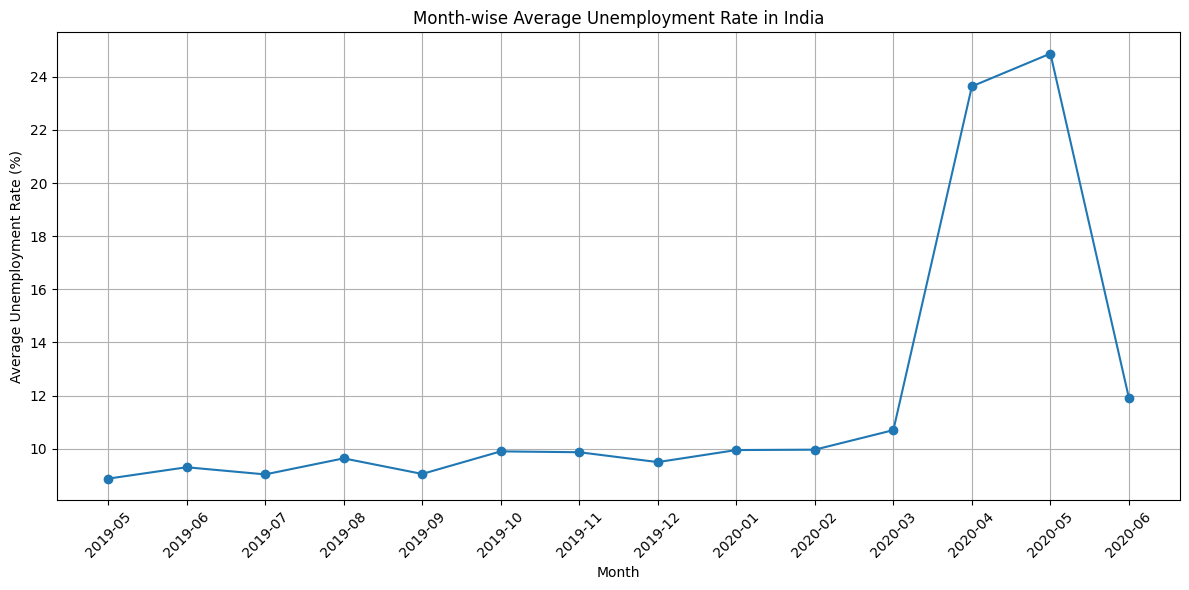

In [12]:
# Extract month from the Date column
df['Month'] = df['Date'].dt.to_period('M').astype(str)

# Calculate average unemployment rate for each month
monthly_unemployment = (
    df.groupby('Month')['Estimated Unemployment Rate (%)']
    .mean()
)

# Create the line chart
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker='o'
)

plt.title('Month-wise Average Unemployment Rate in India')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

The month-wise trend shows how the average unemployment rate changed over the period covered by the dataset. The unemployment rate remained relatively lower during much of 2019 but increased significantly in 2020. The sharp rise during the later months indicates a major change in employment conditions during the COVID-19 period.

### 4.4 Unemployment Trends Across Selected Regions

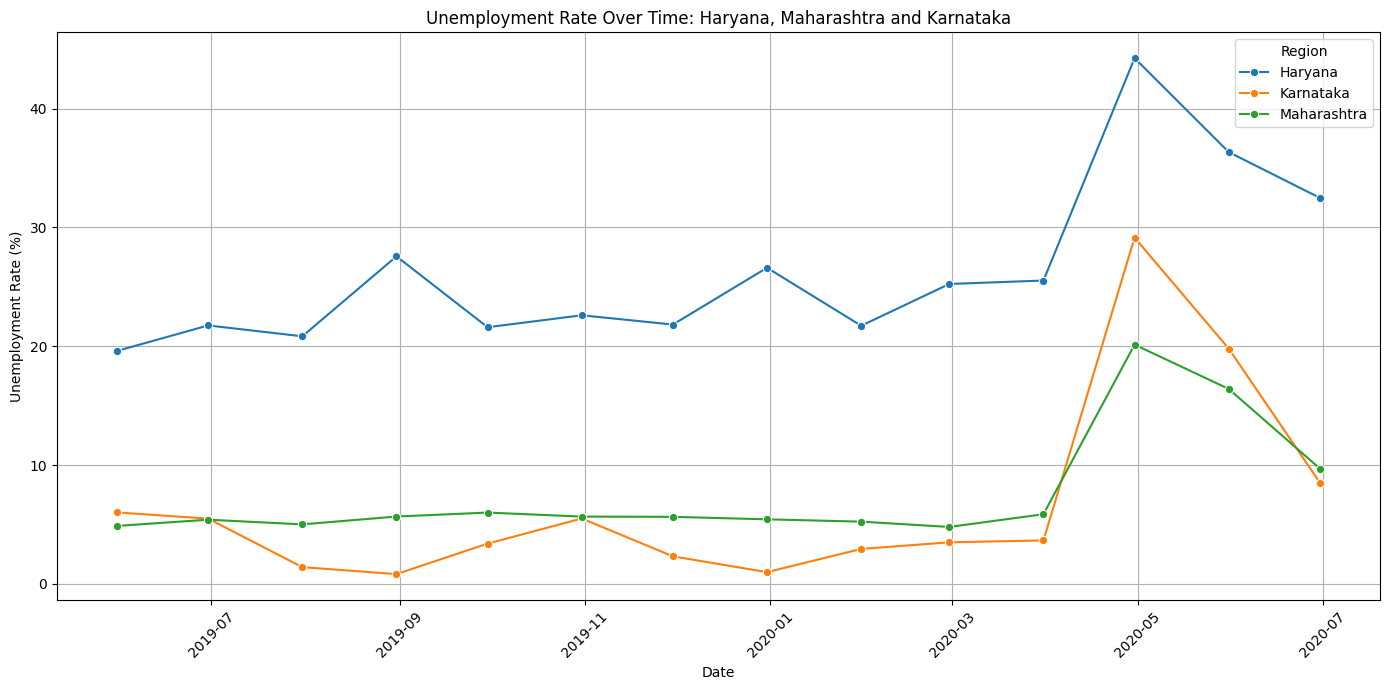

In [13]:
# Select three major regions for comparison
selected_regions = ['Haryana', 'Maharashtra', 'Karnataka']

# Filter the dataset for the selected regions
region_data = df[df['Region'].isin(selected_regions)]

# Calculate average unemployment rate by date for each selected region
region_trends = (
    region_data
    .groupby(['Date', 'Region'])['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
)

# Create the time-series line chart
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=region_trends,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Region',
    marker='o'
)

plt.title('Unemployment Rate Over Time: Haryana, Maharashtra and Karnataka')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.legend(title='Region')

plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

The time-series chart compares unemployment rate trends across Haryana, Maharashtra, and Karnataka. The unemployment rates vary across the three regions throughout the observed period. A noticeable increase can be observed around the COVID-19 period, indicating the impact of the pandemic on employment conditions. The magnitude of change differs between regions, highlighting regional differences in the unemployment situation.

### 4.5 Correlation Analysis

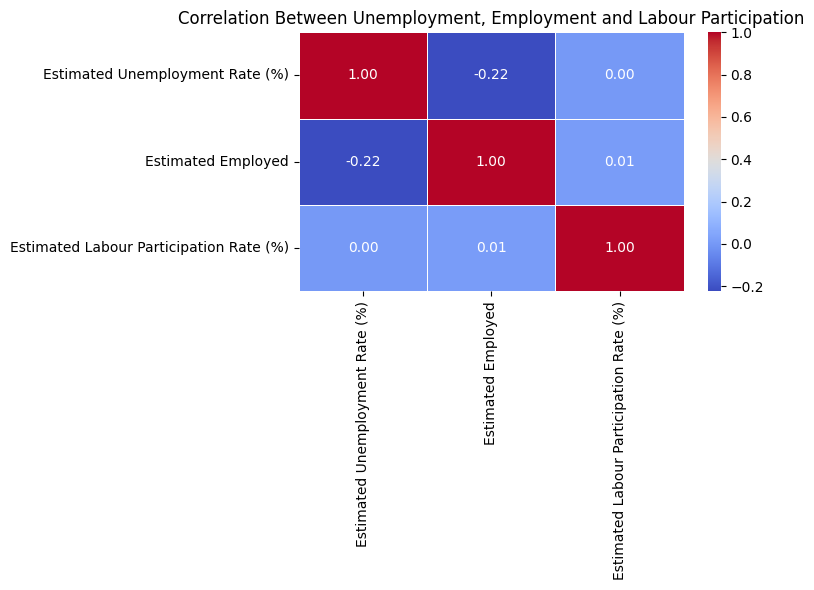

In [14]:
# Select the variables required for correlation analysis
correlation_data = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Create the heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Between Unemployment, Employment and Labour Participation')

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the relationships between unemployment rate, estimated employment, and labour participation rate. The correlation values help identify whether changes in one variable are associated with changes in another. The strength and direction of these relationships can be interpreted from the correlation coefficients shown in the heatmap.

## 5. Pre-COVID vs COVID Period Analysis

In [15]:
# Define the COVID-19 comparison date
covid_start_date = pd.Timestamp('2020-03-01')

# Split the dataset into pre-COVID and COVID periods
pre_covid = df[df['Date'] < covid_start_date]
covid_period = df[df['Date'] >= covid_start_date]

# Calculate mean values for both periods
comparison = pd.DataFrame({
    'Pre-COVID': [
        pre_covid['Estimated Unemployment Rate (%)'].mean(),
        pre_covid['Estimated Employed'].mean(),
        pre_covid['Estimated Labour Participation Rate (%)'].mean()
    ],
    'COVID Period': [
        covid_period['Estimated Unemployment Rate (%)'].mean(),
        covid_period['Estimated Employed'].mean(),
        covid_period['Estimated Labour Participation Rate (%)'].mean()
    ]
}, index=[
    'Unemployment Rate (%)',
    'Estimated Employed',
    'Labour Participation Rate (%)'
])

# Display the comparison
print("Pre-COVID vs COVID Period Comparison:")
display(comparison)

Pre-COVID vs COVID Period Comparison:


,Pre-COVID,COVID Period
Unemployment Rate (%),9.509534e+00,1.777436e+01
Estimated Employed,7.466028e+06,6.517203e+06
Labour Participation Rate (%),4.388612e+01,3.933005e+01


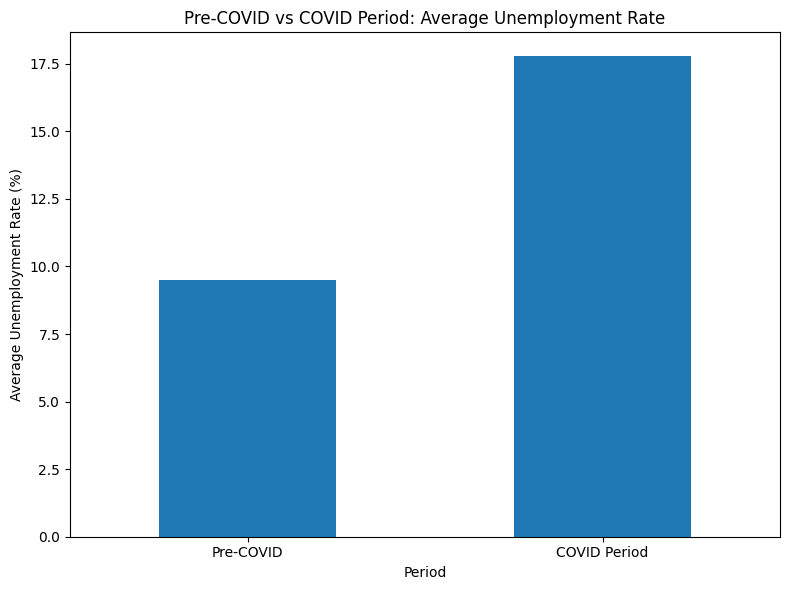

In [16]:
# Create a bar chart comparing pre-COVID and COVID-period unemployment rates
plt.figure(figsize=(8, 6))

comparison.loc['Unemployment Rate (%)'].plot(
    kind='bar'
)

plt.title('Pre-COVID vs COVID Period: Average Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The comparison shows a significant change in employment conditions during the COVID-19 period. The average unemployment rate increased from 9.51% in the pre-COVID period to 17.77% during the COVID period. At the same time, the average estimated number of employed people decreased from approximately 7.47 million to 6.52 million.

The labour participation rate also decreased from 43.89% before COVID-19 to 39.33% during the COVID period. These results indicate that the COVID-19 period was associated with a substantial increase in unemployment, a decline in estimated employment, and a reduction in labour force participation in the regions covered by the dataset.

## 12. Conclusion

This analysis explored unemployment trends in India using regional and time-based data. The dataset was cleaned and analyzed to understand regional differences, monthly trends, and relationships between unemployment, employment, and labour participation.

The analysis showed considerable variation in average unemployment rates across different regions. The time-series analysis also indicated changes in unemployment rates over the observed period. The comparison between the pre-COVID and COVID periods showed a substantial increase in average unemployment from 9.51% to 17.77%, while estimated employment and labour participation decreased.

Overall, the findings highlight the significant impact of the COVID-19 period on employment conditions in India and demonstrate the importance of analyzing unemployment trends across both time and regions.